# 🌳 Árbol de Decisión CART — Clasificación Binaria (Dogs API)

Notebook para entrenar y evaluar un **DecisionTreeClassifier (CART)** usando el dataset de razas de perros de nuestra API.

- **Objetivo (y)**: `hipoalergenico` (1 = Sí, 0 = No)
- **Predictores (X)**: variables numéricas + `categoria_peso` (one-hot) + variables de fecha

Estructura inspirada en `arbol_decision_clasificacion_clima.ipynb`, adaptado a `dogs_normalized.csv`.


## I. Configuración Inicial — Importaciones y Estilo Visual


In [27]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# Estilo visual consistente con el proyecto
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Librerías importadas correctamente')
print(f'   pandas   {pd.__version__}')
print(f'   numpy    {np.__version__}')
print(f'   seaborn  {sns.__version__}')
print('\n⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.')


✅ Librerías importadas correctamente
   pandas   2.3.3
   numpy    2.4.3
   seaborn  0.13.2

⚠️  Nota: El árbol CART no requiere StandardScaler — se usa X_raw directamente.


## II. Carga de Datos desde CSV (Dogs API)


In [28]:
# ── CELDA 2: Carga CSV ─────────────────────────────────────────────────────────
df_raw = pd.read_csv('../data/dogs_normalized.csv')

print(f'✅ Datos cargados: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
print(f"\nColumnas disponibles:\n{df_raw.columns.tolist()}")

df_raw.head()


✅ Datos cargados: 283 filas × 11 columnas

Columnas disponibles:
['raza', 'vida_min', 'vida_max', 'vida_promedio', 'peso_macho_max', 'peso_hembra_max', 'peso_promedio', 'categoria_peso', 'diferencia_sexual_peso', 'hipoalergenico', 'fecha_extraccion']


,raza,vida_min,vida_max,vida_promedio,peso_macho_max,peso_hembra_max,peso_promedio,categoria_peso,diferencia_sexual_peso,hipoalergenico,fecha_extraccion
0,Affenpinscher,14,16,15.0,5,5,5.0,Muy pequeño,0,True,2026-03-26T12:16:51.082919
1,Afghan Hound,12,14,13.0,27,25,26.0,Mediano,2,False,2026-03-26T12:16:51.082954
2,Airedale Terrier,12,14,13.0,23,20,21.5,Mediano,3,False,2026-03-26T12:16:51.082964
3,Akita,10,12,11.0,60,50,55.0,Gigante,10,False,2026-03-26T12:16:51.082972
4,Alaskan Klee Kai,12,15,13.5,7,7,7.0,Muy pequeño,0,False,2026-03-26T12:16:51.082980


## III. Validación y Exploración del Dataset


In [29]:
# ── CELDA 3: Validación y Exploración ────────────────────────────────────────
print('=' * 55)
print('VALIDACIÓN DEL DATASET (DOGS)')
print('=' * 55)

print('\n📋 Tipos de datos y valores nulos:')
print(df_raw.dtypes.to_frame('dtype').join(df_raw.isnull().sum().to_frame('nulos')))

hipo = df_raw['hipoalergenico'].astype(str).str.lower().map({'true': 1, 'false': 0})

print('\n🎯 Balance de la variable objetivo (hipoalergenico):')
counts = hipo.value_counts(dropna=False)
pct = hipo.value_counts(normalize=True, dropna=False) * 100
c1 = int(counts.get(1, 0)); c0 = int(counts.get(0, 0))
p1 = float(pct.get(1, 0.0)); p0 = float(pct.get(0, 0.0))
print(f'   Hipoalergénico (1): {c1:,}  ({p1:.1f}%)')
print(f'   No hipoalerg. (0): {c0:,}  ({p0:.1f}%)')

print('\n📦 Distribución categoria_peso:')
print(df_raw['categoria_peso'].value_counts().to_string())

print('\n📊 Resumen numérico (vida_promedio, peso_promedio, diferencia_sexual_peso):')
print(df_raw[['vida_promedio', 'peso_promedio', 'diferencia_sexual_peso']].describe().round(2))


VALIDACIÓN DEL DATASET (DOGS)

📋 Tipos de datos y valores nulos:
                          dtype  nulos
raza                     object      0
vida_min                  int64      0
vida_max                  int64      0
vida_promedio           float64      0
peso_macho_max            int64      0
peso_hembra_max           int64      0
peso_promedio           float64      0
categoria_peso           object      0
diferencia_sexual_peso    int64      0
hipoalergenico             bool      0
fecha_extraccion         object      0

🎯 Balance de la variable objetivo (hipoalergenico):
   Hipoalergénico (1): 13  (4.6%)
   No hipoalerg. (0): 270  (95.4%)

📦 Distribución categoria_peso:
categoria_peso
Grande         78
Muy pequeño    62
Mediano        54
Pequeño        47
Gigante        42

📊 Resumen numérico (vida_promedio, peso_promedio, diferencia_sexual_peso):
       vida_promedio  peso_promedio  diferencia_sexual_peso
count         283.00         283.00                  283.00
mean        

## IV. Preprocesamiento de Datos


In [30]:
# ── CELDA 4: Preprocesamiento ─────────────────────────────────────────────────
df = df_raw.copy()

# 4.1 Convertir fecha_extraccion y crear features de fecha
# (si falla, queda NaT)
df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'], errors='coerce')
df['mes'] = df['fecha_extraccion'].dt.month
# 0=Lunes … 6=Domingo
df['dia_semana'] = df['fecha_extraccion'].dt.dayofweek

# 4.2 Feature engineering: log(peso_promedio)
df['peso_promedio'] = pd.to_numeric(df['peso_promedio'], errors='coerce')
df['log_peso'] = np.log(df['peso_promedio'].clip(lower=1e-6))

# 4.3 Target: hipoalergenico -> 0/1
df['hipoalergenico'] = df['hipoalergenico'].astype(str).str.lower().map({'true': 1, 'false': 0})

# 4.4 Relleno de nulos en numéricas con mediana
num_cols = ['vida_promedio', 'peso_promedio', 'log_peso', 'diferencia_sexual_peso', 'mes', 'dia_semana']
for col in num_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        df[col] = df[col].fillna(df[col].median())

# 4.5 One-Hot Encoding de categoria_peso
df = pd.get_dummies(df, columns=['categoria_peso'], drop_first=True, dtype=int)

# 4.6 Definir X e y
# Quitamos columnas no predictoras o redundantes
_drop = ['raza', 'fecha_extraccion', 'hipoalergenico', 'vida_min', 'vida_max',
         'peso_macho_max', 'peso_hembra_max']
drop_cols = [c for c in _drop if c in df.columns]

X = df.drop(columns=drop_cols)
y = df['hipoalergenico']

print('✅ Preprocesamiento completado')
print(f'   Shape X: {X.shape}')
print(f'   Columnas finales: {X.columns.tolist()}')
print(f"\n   Clases en y → 0: {(y==0).sum():,}  |  1: {(y==1).sum():,}")
print('\n⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.')


✅ Preprocesamiento completado
   Shape X: (283, 10)
   Columnas finales: ['vida_promedio', 'peso_promedio', 'diferencia_sexual_peso', 'mes', 'dia_semana', 'log_peso', 'categoria_peso_Grande', 'categoria_peso_Mediano', 'categoria_peso_Muy pequeño', 'categoria_peso_Pequeño']

   Clases en y → 0: 270  |  1: 13

⚠️  No se aplica StandardScaler — los árboles CART son invariantes al escalado.


## V. Entrenamiento y Evaluación — Tres Splits


In [31]:
# ── CELDA 5: Función de entrenamiento + evaluación ───────────────────────────

def entrenar_evaluar(X, y, test_size, random_state=42, nombre='Split', max_depth=None):
    '''
    Entrena DecisionTreeClassifier con un split train/test y devuelve
    un dict con métricas + datos para curva ROC y matriz de confusión.

    Parámetros CART:
      - criterion='gini'          : impureza Gini (CART estándar)
      - class_weight='balanced'   : compensa desbalance si existe
      - max_depth                 : None = árbol sin límite (cuidado overfitting)
    '''
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    modelo = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=random_state,
    )
    modelo.fit(X_train, y_train)

    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    return {
        'nombre'    : nombre,
        'train_size': len(X_train),
        'test_size' : len(X_test),
        'accuracy'  : accuracy_score(y_test, y_pred),
        'precision' : precision_score(y_test, y_pred, zero_division=0),
        'recall'    : recall_score(y_test, y_pred, zero_division=0),
        'f1'        : f1_score(y_test, y_pred, zero_division=0),
        'roc_auc'   : roc_auc_score(y_test, y_prob),
        'fpr'       : fpr,
        'tpr'       : tpr,
        'y_test'    : y_test,
        'y_pred'    : y_pred,
        'modelo'    : modelo,
    }

print('✅ Función entrenar_evaluar() definida correctamente')
print("   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'")


✅ Función entrenar_evaluar() definida correctamente
   · DecisionTreeClassifier — criterio Gini, class_weight='balanced'


In [32]:
# ── CELDA 6: Ejecutar los tres splits ────────────────────────────────────────
resultados = [
    entrenar_evaluar(X, y, test_size=0.20, nombre='Split 80/20'),
    entrenar_evaluar(X, y, test_size=0.40, nombre='Split 60/40'),
    entrenar_evaluar(X, y, test_size=0.30, nombre='Split 70/30'),
]

print('=' * 65)
print(f"{'MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART (DOGS)':^65}")
print('=' * 65)
header = f"{'Split':<12} {'N Train':>8} {'N Test':>8} {'Acc':>7} {'Prec':>7} {'Recall':>7} {'F1':>7} {'AUC':>7}"
print(header)
print('-' * 65)
for r in resultados:
    print(
        f"{r['nombre']:<12} {r['train_size']:>8,} {r['test_size']:>8,}"
        f" {r['accuracy']:>7.4f} {r['precision']:>7.4f}"
        f" {r['recall']:>7.4f} {r['f1']:>7.4f} {r['roc_auc']:>7.4f}"
    )
print('=' * 65)


      MÉTRICAS COMPARATIVAS — ÁRBOL DE DECISIÓN CART (DOGS)      
Split         N Train   N Test     Acc    Prec  Recall      F1     AUC
-----------------------------------------------------------------
Split 80/20       226       57  0.7544  0.1333  0.6667  0.2222  0.7593
Split 60/40       169      114  0.6930  0.0588  0.4000  0.1026  0.6009
Split 70/30       198       85  0.6941  0.0769  0.5000  0.1333  0.6497


## VI. Búsqueda de Hiperparámetros — `max_depth` Óptimo


🏆 Mejor max_depth según F1-Score (test): 6
   F1-Score test en depth=6: 0.2222


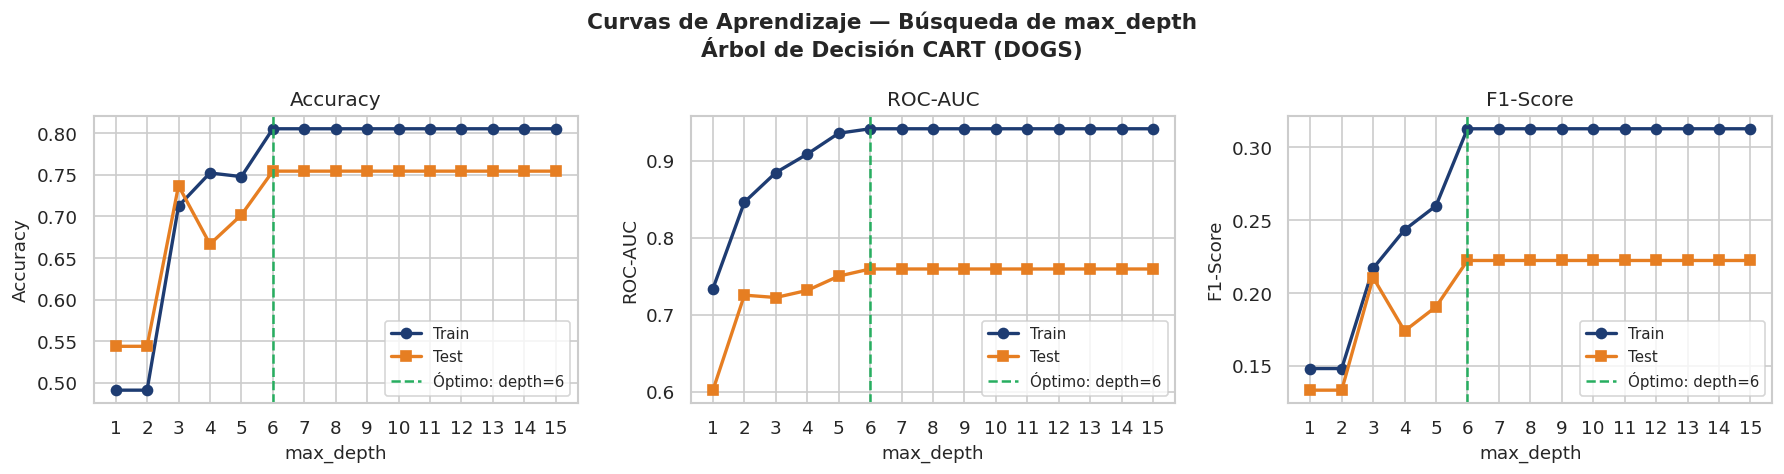

✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_dogs.png


In [33]:
# ── CELDA 7: Búsqueda de max_depth óptimo ────────────────────────────────────
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

profundidades = range(1, 16)
acc_train, acc_test = [], []
auc_train, auc_test = [], []
f1_train,  f1_test  = [], []

for d in profundidades:
    m = DecisionTreeClassifier(
        criterion='gini', max_depth=d,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=42
    )
    m.fit(X_tr, y_tr)

    acc_train.append(accuracy_score(y_tr, m.predict(X_tr)))
    auc_train.append(roc_auc_score(y_tr, m.predict_proba(X_tr)[:, 1]))
    f1_train.append(f1_score(y_tr, m.predict(X_tr), zero_division=0))

    acc_test.append(accuracy_score(y_te, m.predict(X_te)))
    auc_test.append(roc_auc_score(y_te, m.predict_proba(X_te)[:, 1]))
    f1_test.append(f1_score(y_te, m.predict(X_te), zero_division=0))

mejor_depth = list(profundidades)[int(np.argmax(f1_test))]
print(f'🏆 Mejor max_depth según F1-Score (test): {mejor_depth}')
print(f'   F1-Score test en depth={mejor_depth}: {max(f1_test):.4f}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Curvas de Aprendizaje — Búsqueda de max_depth\nÁrbol de Decisión CART (DOGS)',
             fontsize=13, fontweight='bold')

metricas_plot = [
    ('Accuracy', acc_train, acc_test),
    ('ROC-AUC',  auc_train, auc_test),
    ('F1-Score', f1_train,  f1_test),
]

for ax, (titulo, train_vals, test_vals) in zip(axes, metricas_plot):
    ax.plot(profundidades, train_vals, 'o-', color='#1e3c72', lw=2, label='Train')
    ax.plot(profundidades, test_vals,  's-', color='#e67e22', lw=2, label='Test')
    ax.axvline(x=mejor_depth, color='#27ae60', linestyle='--', lw=1.5, label=f'Óptimo: depth={mejor_depth}')
    ax.set_xlabel('max_depth', fontsize=11)
    ax.set_ylabel(titulo, fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.legend(fontsize=9)
    ax.set_xticks(list(profundidades))

plt.tight_layout()
plt.savefig('../data/graficas/max_depth_arbol_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curvas de max_depth guardadas en data/graficas/max_depth_arbol_dogs.png')


## VII. Visualizaciones


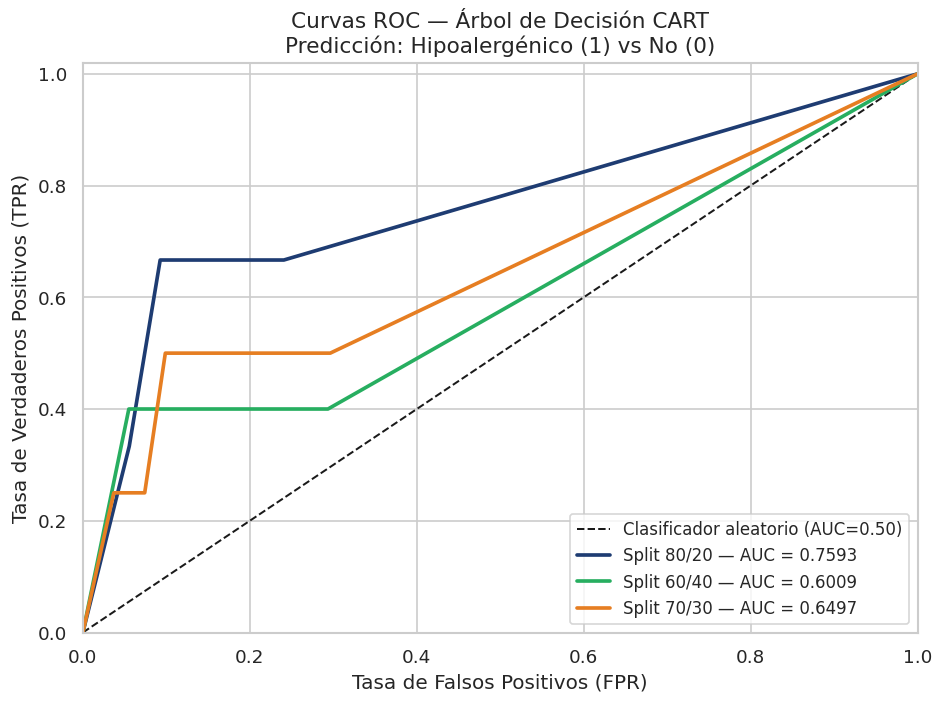

✅ Curvas ROC guardadas en data/graficas/roc_arbol_dogs.png


In [34]:
# ── CELDA 8: Curvas ROC comparativas ─────────────────────────────────────────
COLORS = ['#1e3c72', '#27ae60', '#e67e22']

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Clasificador aleatorio (AUC=0.50)')

for r, color in zip(resultados, COLORS):
    ax.plot(r['fpr'], r['tpr'], color=color, lw=2.2,
            label=f"{r['nombre']} — AUC = {r['roc_auc']:.4f}")

ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — Árbol de Decisión CART\nPredicción: Hipoalergénico (1) vs No (0)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('../data/graficas/roc_arbol_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Curvas ROC guardadas en data/graficas/roc_arbol_dogs.png')


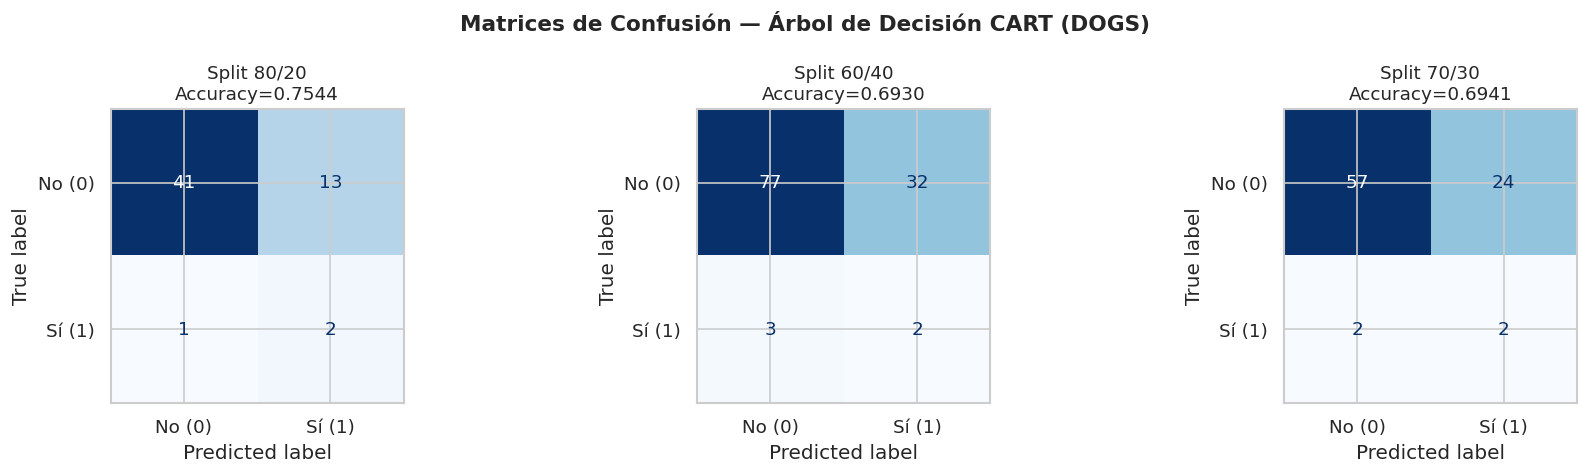

✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_dogs.png


In [35]:
# ── CELDA 9: Matrices de Confusión (3 splits) ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Matrices de Confusión — Árbol de Decisión CART (DOGS)', fontsize=13, fontweight='bold')

for ax, r in zip(axes, resultados):
    cm = confusion_matrix(r['y_test'], r['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No (0)', 'Sí (1)'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{r['nombre']}\nAccuracy={r['accuracy']:.4f}", fontsize=11)

plt.tight_layout()
plt.savefig('../data/graficas/confusion_arbol_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Matrices de confusión guardadas en data/graficas/confusion_arbol_dogs.png')


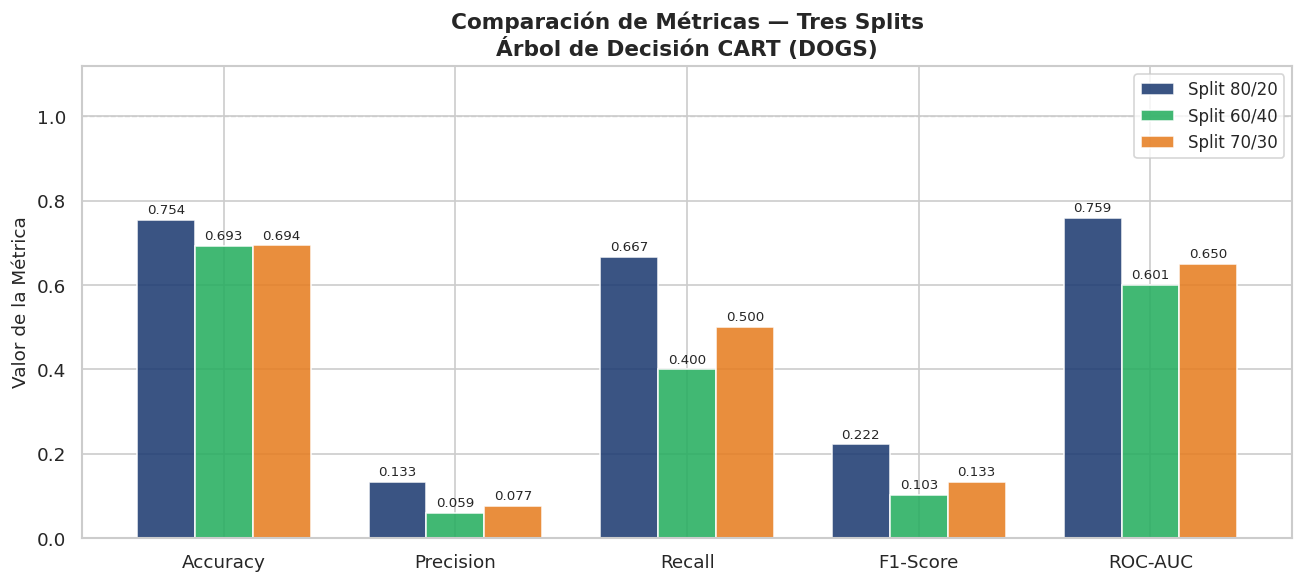

✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_dogs.png


In [36]:
# ── CELDA 10: Gráfico comparativo de métricas ───────────────────────────────
metricas_nombres = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
etiquetas = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

x = np.arange(len(etiquetas))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (r, color) in enumerate(zip(resultados, COLORS)):
    vals = [r[m] for m in metricas_nombres]
    bars = ax.bar(x + i * width, vals, width, label=r['nombre'], color=color, alpha=0.88)
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(etiquetas, fontsize=11)
ax.set_ylim([0, 1.12])
ax.set_ylabel('Valor de la Métrica', fontsize=11)
ax.set_title('Comparación de Métricas — Tres Splits\nÁrbol de Decisión CART (DOGS)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.axhline(y=1.0, color='#ccc', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.savefig('../data/graficas/metricas_comparativas_arbol_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Gráfico de métricas guardado en data/graficas/metricas_comparativas_arbol_dogs.png')


## VIII. Importancia de Variables — Feature Importance (Gini)


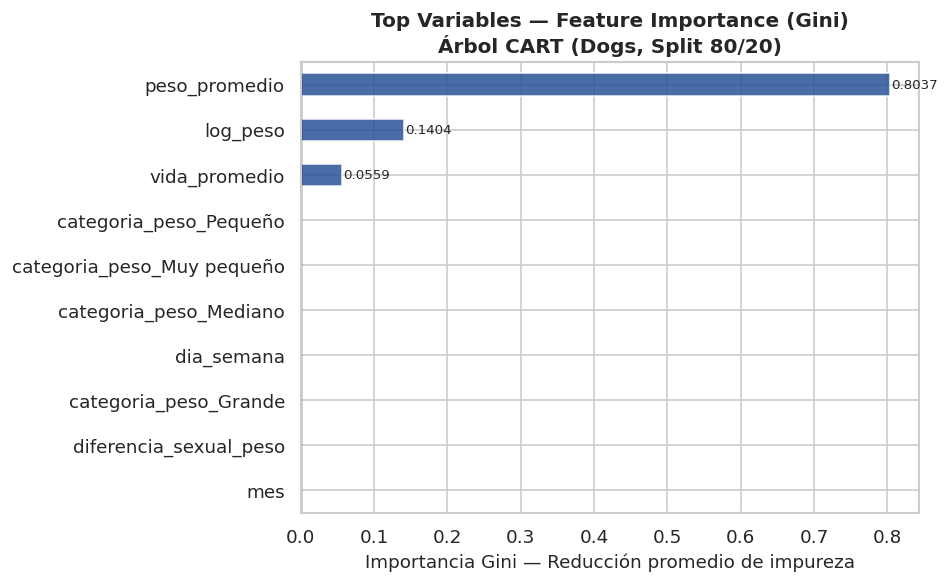

✅ Feature importance guardada en data/graficas/feature_importance_arbol_dogs.png

📊 Suma de todas las importancias: 1.000000  (debe ser ≈ 1.0)

Top 5 variables más importantes:
peso_promedio             0.803723
log_peso                  0.140412
vida_promedio             0.055865
diferencia_sexual_peso    0.000000
mes                       0.000000


In [37]:
# ── CELDA 11: Importancia de variables (Feature Importance Gini) ─────────────
modelo_ref = resultados[0]['modelo']
importancias = pd.Series(modelo_ref.feature_importances_, index=X.columns)
importancias_ord = importancias.sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(8, 5))
importancias_ord.plot(kind='barh', ax=ax, color='#2a5298', alpha=0.85)
ax.set_xlabel('Importancia Gini — Reducción promedio de impureza', fontsize=11)
ax.set_title('Top Variables — Feature Importance (Gini)\nÁrbol CART (Dogs, Split 80/20)', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)

for patch in ax.patches:
    w = patch.get_width()
    if w > 0.001:
        ax.text(w + 0.002, patch.get_y() + patch.get_height() / 2,
                f'{w:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('../data/graficas/feature_importance_arbol_dogs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Feature importance guardada en data/graficas/feature_importance_arbol_dogs.png')
print(f"\n📊 Suma de todas las importancias: {importancias.sum():.6f}  (debe ser ≈ 1.0)")
print('\nTop 5 variables más importantes:')
print(importancias.sort_values(ascending=False).head(5).to_string())


## IX. Tabla Final de Métricas


In [38]:
# ── CELDA 12: DataFrame resumen de métricas ──────────────────────────────────
resumen = pd.DataFrame([{
    'Split'          : r['nombre'],
    'N Entrenamiento': r['train_size'],
    'N Prueba'       : r['test_size'],
    'Accuracy'       : round(r['accuracy'],  4),
    'Precision'      : round(r['precision'], 4),
    'Recall'         : round(r['recall'],    4),
    'F1-Score'       : round(r['f1'],        4),
    'ROC-AUC'        : round(r['roc_auc'],   4),
} for r in resultados])

resumen.set_index('Split', inplace=True)

print('=' * 65)
print(f"{'TABLA FINAL DE MÉTRICAS':^65}")
print('=' * 65)
display(
    resumen.style
        .background_gradient(cmap='Greens', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
        .format('{:.4f}', subset=['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'])
        .set_caption('Árbol de Decisión CART — Clasificación Binaria: Hipoalergénico (Dogs API)')
)

print(f"\n📌 Mejor depth encontrado en sección VI (según F1 test): {mejor_depth}")


                     TABLA FINAL DE MÉTRICAS                     


,N Entrenamiento,N Prueba,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,,,
Split 80/20,226,57,0.7544,0.1333,0.6667,0.2222,0.7593
Split 60/40,169,114,0.6930,0.0588,0.4000,0.1026,0.6009
Split 70/30,198,85,0.6941,0.0769,0.5000,0.1333,0.6497



📌 Mejor depth encontrado en sección VI (según F1 test): 6


## X. Conclusiones

- CART divide el espacio en reglas tipo **if/else** (cortes por umbrales), capturando no linealidades.
- Con clases desbalanceadas, **F1-Score** y **ROC-AUC** suelen ser más informativas que solo Accuracy.
- Si el árbol sobreajusta, ajustar `max_depth`, `min_samples_leaf` y `min_samples_split` mejora generalización.
- `feature_importances_` (Gini) indica qué variables ayudan más a separar `hipoalergenico`.
